In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install --upgrade diffusers transformers -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 112.6 MB/s eta 0:00:00


In [7]:
from huggingface_hub import notebook_login

notebook_login()

In [8]:
from pathlib import Path
import tqdm
import torch
import pandas as pd
import numpy as np
from diffusers import StableDiffusionPipeline
from transformers import pipeline, set_seed
import matplotlib.pyplot as plt
import cv2

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

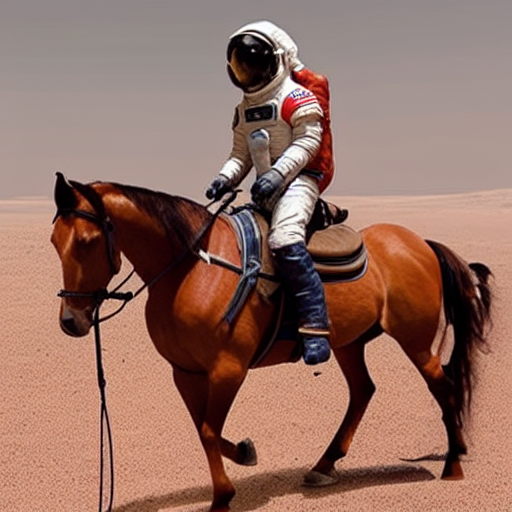

In [10]:
import torch
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler

model_id = "runwayml/stable-diffusion-v1-5"

# Use the DPMSolverMultistepScheduler (DPM-Solver++) scheduler here instead
pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

pipe.scheduler = DPMSolverMultistepScheduler.from_config(
    pipe.scheduler.config
)

pipe = pipe.to("cuda")

prompt = "a photo of an astronaut riding a horse on mars"

image = pipe(prompt).images[0]

image.save("/content/drive/MyDrive/astronaut_rides_horse.png")

image

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

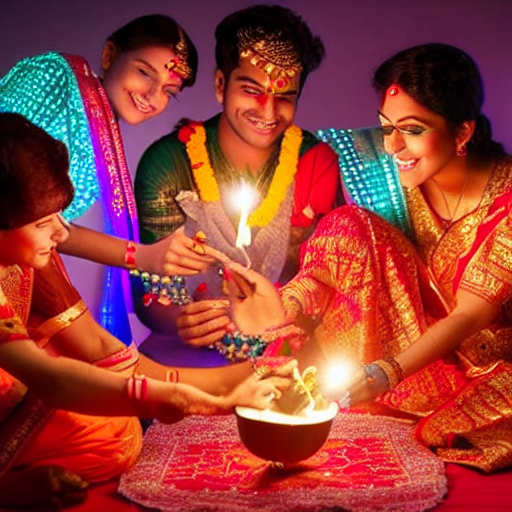

In [13]:
import torch
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler

model_id = "runwayml/stable-diffusion-v1-5"

# Use the DPMSolverMultistepScheduler (DPM-Solver++) scheduler here instead
pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

pipe.scheduler = DPMSolverMultistepScheduler.from_config(
    pipe.scheduler.config
)

pipe = pipe.to("cuda")

prompt = "Indians are celebrating Diwali festival in India, wearing traditional clothes, colorful lights, beautiful decorations, realistic photography"

image = pipe(prompt).images[0]

image.save("diwali.png")

image

In [15]:
# compvis model integrain with stabel diffusion model

import torch
from diffusers import StableDiffusionPipeline

model_id = "CompVis/stable-diffusion-v1-4"
device = "cuda"


pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)
pipe = pipe.to(device)

prompt = "a photo birds flying in moon "
image = pipe(prompt).images[0]

image.save("birds.png")


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

In [16]:
!nvidia-smi

Mon Jul 27 10:16:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             34W /   70W |    3967MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [23]:
import torch
from diffusers import StableDiffusionPipeline


class CFG:
    device = "cuda" if torch.cuda.is_available() else "cpu"
    seed = 42

    generator = torch.Generator(device).manual_seed(seed)

    image_gen_steps = 35

    # Changed model only
    image_gen_model_id = "runwayml/stable-diffusion-v1-5"

    image_gen_size = (400, 400)

    image_gen_guidance_scale = 9

    prompt_gen_model_id = "gpt-omni/mini-omni"
    prompt_dataset_size = 6
    prompt_max_lenghth = 12


# Load Stable Diffusion Model
image_gen_model = StableDiffusionPipeline.from_pretrained(
    CFG.image_gen_model_id,
    torch_dtype=torch.float16
)


# Move model to GPU
image_gen_model = image_gen_model.to(CFG.device)


print("Model loaded successfully!")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Model loaded successfully!


In [24]:
def generate_images(prompt, model, num_images=3):
    images = []

    for i in range(num_images):
        image = model(
            prompt,
            num_inference_steps=CFG.image_gen_steps,
            generator=CFG.generator,
            guidance_scale=CFG.image_gen_guidance_scale
        ).images[0]

        image = image.resize(CFG.image_gen_size)
        images.append(image)

    return images

In [27]:
image1 = generate_image(
    "People are dancing happily, traditional clothes, colorful festival celebration, beautiful lights, realistic photography, high quality",
    image_gen_model
)

image2 = generate_image(
    "Kids eating icecream, happy children, summer day, colorful icecream, outdoor park, realistic photography, high quality",
    image_gen_model
)

image3 = generate_image(
    "Beautiful green forest, tall trees, sunlight coming through leaves, nature scenery, realistic photography, high quality",
    image_gen_model
)

  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

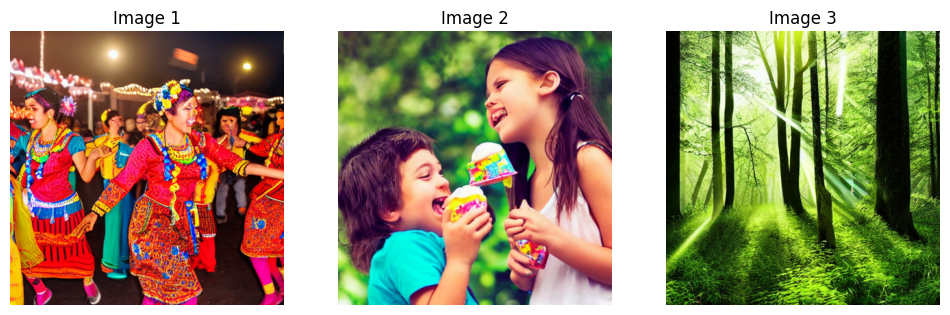

In [28]:
import matplotlib.pyplot as plt

images = [image1, image2, image3]

plt.figure(figsize=(12,4))

for i, img in enumerate(images):
    plt.subplot(1,3,i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Image {i+1}")

plt.show()

In [29]:
image1.save("people_dancing.png")
image2.save("kids_eating_icecream.png")
image3.save("forest.png")